In [16]:
from langgraph.graph import StateGraph , START , END
from pydantic import BaseModel , Field 
from langchain_google_genai import ChatGoogleGenerativeAI
import operator
from typing import TypedDict , Annotated  , Literal
from dotenv import load_dotenv
load_dotenv()


True

In [17]:
class State_Schema(TypedDict):
    topic : str
    joke : str
    iteration:int 
    max_iteration:int
    evaluation : Literal['accepted' , 'rejected']
    feedback : Annotated[list[str],operator.add]
    jokes_history :  Annotated[list[str],operator.add]


In [18]:
genration_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
evaluation_llm = ChatGoogleGenerativeAI(model="gemini-3.7-flash")
optimizer_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")



In [19]:
class evaluation_schema(BaseModel):
    evaluation: Literal['accepted' , 'rejected'] = Field(description="review the joke given to you and respond accrodingly , wheather to accept it or reject it .")
    feedback : str = Field(description="""review the provided joke and give the feedback on the following parameters  : 
    Clarity → Is the joke easy to understand without over‑explaining?

Timing/Pacing → Does the punchline land at the right moment?

Originality → Is it fresh, or does it feel like a recycled gag?

Relevance → Does it connect to the audience’s context or shared knowledge?

Surprise Factor → Does it twist expectations in a clever way?
Humor Intensity → How strongly does it make people laugh or smile?

Relatability → Can the audience see themselves in the situation?

Playfulness → Does it feel lighthearted rather than forced?""")

In [20]:
structured_evaluation_llm = evaluation_llm.with_structured_output(evaluation_schema)

In [21]:
def genrate(state:State_Schema):
    prompt = f""" You are a comedy writer tasked with creating a short joke. 
Make sure the joke is:
- Clear and easy to understand
- Timed so the punchline lands naturally
- Original and not a cliché
- Relevant to everyday life or common experiences
- Surprising with a clever twist
- Playful and lighthearted
- Appropriate for a general audience (avoid offensive stereotypes) , 
genrate a joke on the topic {state['topic']}  , 
avoid going into the question answer format and strictly follow the given rules to you , and avoid chatting with the user , just start genrating the joke immediately , without addressing the user."""

    response = genration_llm.invoke(prompt)

    return {'joke':response.content , 'jokes_history':[response.content] , 'iteration':state['iteration']+1}

In [22]:
def evaluate(state:State_Schema):
    prompt= f""" evluate the joke : {state['joke']} , and give your take on this ."""

    response = structured_evaluation_llm.invoke(prompt)

    return {
        "evaluation":response.evaluation , 
        "feedback" : [response.feedback], 
    }

In [23]:
def optimize(state:State_Schema):
    prompt = f"""optimize this joke :  {state['joke']} , and using the feedback {state['feedback']} , based on the following parameters : 
    Make sure the joke is:
- Clear and easy to understand
- Timed so the punchline lands naturally
- Original and not a cliché
- Relevant to everyday life or common experiences
- Surprising with a clever twist
- Playful and lighthearted
-the length of the joke should be lower then the 280 words.
- Appropriate for a general audience (avoid offensive stereotypes) , 
genrate a joke on the topic   , 
avoid going into the question answer format and strictly follow the given rules to you , and avoid chatting with the user , just start genrating the joke immediately , without addressing the user."""

    response = optimizer_llm.invoke(prompt)

    return {
        'joke':response.content , 
        'jokes_history':[response.content] , 'iteration':state['iteration']+1

    }

In [24]:
def conditional_function(state:State_Schema):
    if state['evaluation']=='accepted' or state['max_iteration']>=5:
        return 'accepted' 
    else:
        return 'rejected'
    

In [25]:
graph = StateGraph(State_Schema)

In [26]:
# adding the nodes 
graph.add_node('evaluate' , evaluate)
graph.add_node('genrate' , genrate)
graph.add_node('optimize' , optimize)



In [27]:
#adding edges 
graph.add_edge(START , 'genrate')
graph.add_edge("genrate",'evaluate')
graph.add_conditional_edges("evaluate" , conditional_function , {'accepted': END , 'rejected':'optimize'})
graph.add_edge('optimize' , 'evaluate')

workflow = graph.compile()

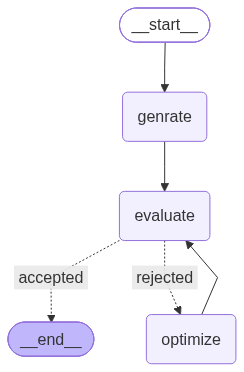

In [28]:
workflow

In [29]:
intial_state = {
    'topic':"dfgkdjfkg",
    "iteration":0
    
}

workflow.invoke(intial_state)

{'topic': 'dfgkdjfkg',
 'joke': 'I finally figured out why my smart speaker keeps ignoring me. It’s not broken; it just thinks my requests sound an awful lot like ambient background noise.',
 'iteration': 1,
 'evaluation': 'accepted',
 'feedback': ["Clarity: High, the premise and punchline are straightforward and easy to grasp immediately. Timing/Pacing: Good, the setup smoothly leads into the self-deprecating punchline without dragging. Originality: Moderate, while smart speaker jokes are common, phrasing the issue as being categorized as 'ambient noise' adds a clever self-deprecating angle. Relevance: Very high, as voice assistants and smart speakers are ubiquitous in modern households. Surprise Factor: Moderate, the turn from a tech glitch to self-worth/insignificance provides a neat twist. Humor Intensity: Mild to moderate, eliciting a relatable chuckle or smirk rather than a belly laugh. Relatability: Strong, anyone who has struggled with voice recognition or felt unheard will con